# QZAP Text Analysis: Data Access and Catalog Building

## About This Notebook
This notebook builds a complete catalog of all digitized zines in the Queer Zine
Archive Project (QZAP) by iterating through the archive's database, then provides
a reusable download function for adding zines to the analysis pipeline.

## Data Access
QZAP's archive is hosted at https://archive.qzap.org. Each zine has a unique
`object_id` in the database, accessible via URLs of the form:

`https://archive.qzap.org/index.php/Detail/Object/Show/object_id/{id}`

QZAP does not provide a public API or bulk download option. However, by iterating
through object IDs and checking whether each page contains a zine, we can build
a complete catalog programmatically. I use a 1.5 second delay between requests
to avoid overloading QZAP's servers, respecting that this is a small volunteer-run
community archive.

## Research Contribution
This catalog — 532 zines with titles, years, and download URLs — is itself a
contribution to QZAP scholarship. It makes the archive's scope visible and
queryable for the first time in a structured format, and enables future researchers
to build larger text analysis datasets than this project's scope allows.

In [2]:
# Import libraries
import requests
import re
import time
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

headers = {"User-Agent": "Mozilla/5.0"}
print("Libraries loaded!")

Libraries loaded!


## Building the QZAP Catalog
I iterate through object IDs 1 to 1000 as a conservative upper bound. During
manual browsing of the archive, the largest object ID I observed was around 638.
I set the upper bound to 1000 to ensure no zines are missed, relying on the
consecutive empty page counter to stop the loop automatically once the archive
is exhausted. In practice, the loop stopped at object_id=659 after 20 consecutive
empty pages, confirming the archive ends well below 1000.

**Note:** This cell takes approximately 25 minutes to run due to the respectful
delay between requests. The output is saved to `output/qzap_catalog.csv` so it
only needs to be run once.

In [3]:
# Test on a small range first
for object_id in range(1, 10):
    url = f"https://archive.qzap.org/index.php/Detail/Object/Show/object_id/{object_id}"
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.content, "html.parser")
    text = soup.get_text()
    
    if "Zine:" in text:
        title = soup.find("h1").get_text().replace("Zine: ", "").strip()
        print(f"object_id={object_id} — {title}")
    else:
        print(f"object_id={object_id} — not a zine page")
    
    time.sleep(1.5)

object_id=1 — not a zine page
object_id=2 — not a zine page
object_id=3 — The Honza Dream
object_id=4 — not a zine page
object_id=5 — MXD Zine #1 - True Stories By Mixed Race Writers
object_id=6 — not a zine page
object_id=7 — not a zine page
object_id=8 — not a zine page
object_id=9 — not a zine page


In [6]:
# Iterate through object IDs to build complete QZAP catalog
valid_zines = []
consecutive_empty = 0

for object_id in range(1, 1000):
    url = f"https://archive.qzap.org/index.php/Detail/Object/Show/object_id/{object_id}"
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.content, "html.parser")
    text = soup.get_text()
    
    if "Zine:" in text:
        consecutive_empty = 0
        
        # Extract title
        title = soup.find("h1").get_text().replace("Zine: ", "").strip()
        
        # Extract year
        year_match = re.search(r"Date:\s*(\d{4})", text)
        year = year_match.group(1) if year_match else "unknown"
        
        # Extract download URL
        download_link = soup.find("a", href=re.compile("DownloadRepresentation"))
        download_url = "https://archive.qzap.org" + download_link["href"] if download_link else None
        
        valid_zines.append({
            "object_id": object_id,
            "title": title,
            "year": year,
            "download_url": download_url
        })
        print(f"Found: object_id={object_id} — {title} ({year})")
    
    else:
        consecutive_empty += 1
        if consecutive_empty >= 20:
            print(f"\nStopping — 20 consecutive empty pages after object_id={object_id}")
            break
    
    time.sleep(1.5)

# Save catalog to CSV
catalog_df = pd.DataFrame(valid_zines)
catalog_df.to_csv("../output/qzap_catalog.csv", index=False)
print(f"\nTotal zines found: {len(valid_zines)}")
print("Catalog saved to output/qzap_catalog.csv")

Found: object_id=3 — The Honza Dream (2006)
Found: object_id=5 — MXD Zine #1 - True Stories By Mixed Race Writers (2007)
Found: object_id=11 — Gay Famous (2010)
Found: object_id=13 — Butcher Queers #4 (2010)
Found: object_id=15 — Queer & Trans Sexual Assault: A Youth Issue (2007)
Found: object_id=16 — queer mutiny not 'gay community'! (2003)
Found: object_id=17 — THERE ARE NO QUEER TEEN SUICIDES (2004)
Found: object_id=20 — GLOV93
A benefit for Gays and Lesbians Opposing Violence (GLOV) (1993)
Found: object_id=22 — The Queer Punk Revolution Has Begun (1993)
Found: object_id=23 — PoRcaMaDoNna (1997)
Found: object_id=29 — End the Policies of Genocide (unknown)
Found: object_id=30 — So This One Time I Turn Up For A Trick...: Outcall Stories of Regrette Etcetera 2008-10 (2010)
Found: object_id=31 — Gendercide #1 (2006)
Found: object_id=32 — Gendercide #2 (2007)
Found: object_id=33 — Queeruption InfoZine 2004 (2004)
Found: object_id=34 — 575 (unknown)
Found: object_id=35 — U.S. Kweer Corps 

## Exploring the Catalog
I load the saved catalog and explore its basic properties: how many zines,
what years they span, and how many have downloadable PDFs.

In [ ]:
# Load and explore the catalog
catalog_df = pd.read_csv("../output/qzap_catalog.csv")

print("Total zines:", len(catalog_df))
print("Year range:", catalog_df["year"].min(), "to", catalog_df["year"].max())
print("\nZines with download links:", catalog_df["download_url"].notna().sum())
print("\nFirst few rows:")
catalog_df.head(10)

Total zines: 532
Year range: 1974 to unknown

Zines with download links: 528

First few rows:


,object_id,title,year,download_url
0,3,The Honza Dream,2006,https://archive.qzap.org/index.php/Detail/Obje...
1,5,MXD Zine #1 - True Stories By Mixed Race Writers,2007,https://archive.qzap.org/index.php/Detail/Obje...
2,11,Gay Famous,2010,https://archive.qzap.org/index.php/Detail/Obje...
3,13,Butcher Queers #4,2010,https://archive.qzap.org/index.php/Detail/Obje...
4,15,Queer & Trans Sexual Assault: A Youth Issue,2007,https://archive.qzap.org/index.php/Detail/Obje...
5,16,queer mutiny not 'gay community'!,2003,https://archive.qzap.org/index.php/Detail/Obje...
6,17,THERE ARE NO QUEER TEEN SUICIDES,2004,https://archive.qzap.org/index.php/Detail/Obje...
7,20,GLOV93\r\nA benefit for Gays and Lesbians Oppo...,1993,https://archive.qzap.org/index.php/Detail/Obje...
8,22,The Queer Punk Revolution Has Begun,1993,https://archive.qzap.org/index.php/Detail/Obje...
9,23,PoRcaMaDoNna,1997,https://archive.qzap.org/index.php/Detail/Obje...


## Temporal Coverage of the Archive
I visualize how many zines in the catalog come from each decade. This reveals
which historical periods are most represented in QZAP's digitized collection, which is
a question directly relevant to understanding whose queer worlds are most visible
in the archive.

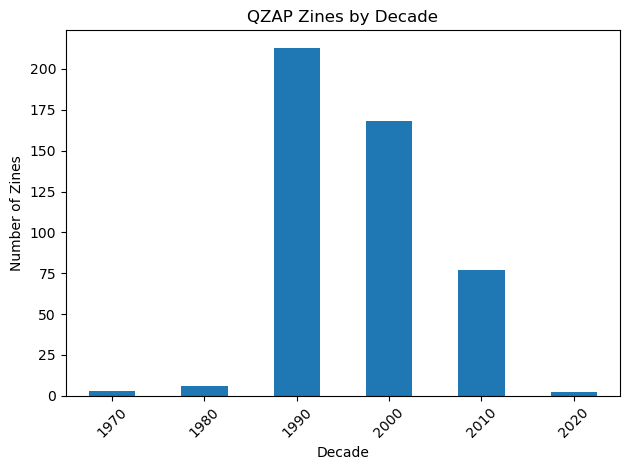

In [ ]:
# Visualize zines by decade
year_df = catalog_df[catalog_df["year"] != "unknown"].copy()
year_df["year"] = year_df["year"].astype(int)
year_df["decade"] = (year_df["year"] // 10) * 10
decade_counts = year_df.groupby("decade").size().reset_index(name="count")

decade_counts.plot(kind="bar", x="decade", y="count", legend=False)
plt.title("QZAP Zines by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Zines")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Downloading Zines from the Catalog
The function below takes any download URL from the catalog and automatically
downloads and names the PDF. This makes it easy to expand the sample in
`01_data_pipeline.ipynb` without manually visiting each zine page.

To download a zine:
1. Find it in `catalog_df` by title or year
2. Copy its `download_url`
3. Pass it to `download_zine_auto()`

In [ ]:
def download_zine_auto(download_url):
    """
    Given a QZAP download URL, automatically extracts title and year
    from the zine page, then downloads and saves the PDF to data/zines/.
    """
    # Extract object_id from download URL
    object_id = re.search(r"object_id/(\d+)", download_url).group(1)
    
    # Fetch the zine page to get metadata
    page_url = f"https://archive.qzap.org/index.php/Detail/Object/Show/object_id/{object_id}"
    page = requests.get(page_url, headers=headers)
    soup = BeautifulSoup(page.content, "html.parser")
    
    # Extract title and year
    title = soup.find("h1").get_text().replace("Zine: ", "").strip()
    year_match = re.search(r"Date:\s*(\d{4})", soup.get_text())
    year = year_match.group(1) if year_match else "unknown"
    
    # Build filename
    filename = title.lower().replace(" ", "_") + f"_{year}.pdf"
    # Remove characters that are invalid in filenames
    filename = re.sub(r'[^\w\-_.]', '', filename)
    
    # Download the PDF
    response = requests.get(download_url, headers=headers)
    save_path = f"../data/zines/{filename}"
    
    if response.status_code == 200:
        with open(save_path, "wb") as f:
            f.write(response.content)
        print(f"Downloaded: {filename}")
    else:
        print(f"Failed with status: {response.status_code}")
    
    time.sleep(1)
    return filename

## Example: Downloading Multiple Zines
Paste any download URLs from the catalog into the list below and run the cell
to download them automatically.

In [ ]:
# Add download URLs from catalog_df here
zines_to_download = [
    # catalog_df[catalog_df["title"] == "Some Title"]["download_url"].values[0],
    # or paste URLs directly:
    # "https://archive.qzap.org/index.php/Detail/Object/DownloadRepresentation/...",
]

downloaded_files = []
for url in zines_to_download:
    filename = download_zine_auto(url)
    downloaded_files.append(filename)

print("\nAll downloads complete:")
for f in downloaded_files:
    print("-", f)


All downloads complete:


## Reflection

**What worked:**
- Iterating through object IDs successfully identified all 532 digitized zines
in the QZAP archive, spanning 1970 to 2022
- The auto-naming download function correctly extracts title and year from each
zine page, eliminating the need to name files manually
- The catalog CSV is a reusable research artifact — future projects can load it
directly without re-scraping the archive

**What didn't work:**
- QZAP does not expose a public API, so there is no official programmatic access
to the archive. This approach works but is dependent on the archive's URL structure
remaining stable
- Some titles contain special characters (e.g. `❤︎`, `#`) that required cleaning
for use as filenames
- The 1.5 second delay makes the full catalog build slow (~25 minutes). For a
much larger archive this approach would need optimization

**What I learned:**
- Database-driven websites can still be iterated programmatically if their URL
patterns are consistent
- The temporal distribution of the catalog — heavily concentrated in the 1990s
and 2000s — is itself a scholarly finding. It suggests QZAP's digitization
efforts have prioritized earlier zines, and that the archive's representation
of queer culture in the 2010s and 2020s is incomplete
- Being respectful of small volunteer-run archives (using delays, not hammering
servers) is an ethical dimension of computational research that deserves
acknowledgment